In this Notebook we explore the propagation of the mean **defect** in LLNAs on Watts-Strogatz networks for various rewiring probabilities.

We will do the following:
- Create W-S graph with $N=100$ nodes for $p \in \{0, 0.2, 1\}$. For $p=0$ we have the familiar case of a CA, and for $p=1$ we have the well-explored case of a Erdös-Renyi random network.
- Choose a particularly interesting rule, preferably one that makes sense as a CA (on a ring graph)
- Take various initial configurations with a particular density, and evolve the system over $T=100$ time steps
- Plot the mean and the variance of the evolution of the densities for a variety of $p$ values
- Plot the final value and variance for all rules of a particular resolution and compare this to the value that is predicted from the mean-field approach

Check out these rules!
- OT-5: birth on 2 or 4, survive on 1-3: produces localised structures, travelling waves etc.
- OT-7: majority voting
- OT-12: only birth on 3, no survival (interesting for edge-of-chaos stuff)

In [2]:
# standard preamble for the Notebooks I use
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *
from src.rules import binary_indices, return_equivalent_rule
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire

%load_ext autoreload
%autoreload 2

# Create a number of networks

Some notes:
- We need to make sure that the network is connected (no separate graphs)
- If we want to turn a ring graph into a random network, the condition for connectedness turns it into a very long waiting time
- If we start with a ring graph (like ECAs), the random networks turn out quite ugly (very unconnected)
- If I want to start off with a Game of Life network, the plotting does not work (makes the whole thing crash). And just making the network already takes a long time! Don't really understand why. I think the `dim=2` kwarg is just broken. There are probably ways around this, but let's just start with a different scenario for now.

Some remarkable rules:
- ...

In [3]:
VISUALISE=False

# Parameters
L = 30                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast
num_nodes = L**2
rewiring_prob = 0.2     # Rewiring probability

# Create toroidal lattice and rewire
lattice_graph = create_2d_torus_lattice(L, degree=8)
small_world_graph = watts_strogatz_rewire(lattice_graph, rewiring_prob)
random_graph = watts_strogatz_rewire(lattice_graph, 1.)

# find edges
lattice_graph.to_directed()
lattice_edges = tc.tensor(lattice_graph.get_edgelist()).T
lattice_graph.to_undirected()

small_world_graph.to_directed()
small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
small_world_graph.to_undirected()

random_graph.to_directed()
random_edges = tc.tensor(random_graph.get_edgelist()).T
random_graph.to_undirected()

# save graphs and edges in list
graphs = [lattice_graph, small_world_graph, random_graph]
graph_names = ["Lattice", f"Small World ($p={rewiring_prob}$)", "Random"]
edges = [lattice_edges, small_world_edges, random_edges]

if VISUALISE:
    # Optional: Visualize
    fig, axs = plt.subplots(1,3,figsize=(15,5))
    layout = lattice_graph.layout("grid")  # Grid layout
    vertex_size  = 5
    edge_width = 0.5
    fontsize = 22

    for ax, graph, name in zip(axs, graphs, graph_names):
        ig.plot(graph, layout=layout, vertex_size=vertex_size, edge_width=edge_width, target=ax)
        ax.set_title(name, fontsize=fontsize)

In [4]:
from src.rules import return_life_like_dict
life_like_dict = return_life_like_dict()
# {'replicator': (170, 170),        # for the lattice, we see interference because of finite grid. For others, convergence to 0.5
#  'seeds': (4, 0),                 # wide range for lattice. remaining d for small-world. d->0 for random.
#  'no_name': (36, 16),             # some defect remains, but not quite interesting
#  'life_without_death': (8, 511),  # defects all quasi die out
#  'life': (8, 12),                 # interesting! quite distinct behaviour. In small-world, the defect dies out. In random, some defect close to 0.5 eventually remains
#  '34_life': (24, 24),             # some defect escapes for lattice, others are identical to each other
#  'diamoeba': (488, 480),          # interesting behaviour for lattice and rho=0.5. Rest is quite boring
#  '2x2': (72, 38),                 # PODIUMPLAATS interesting and distinct behaviour for three networks and rho0. Defect is almost 50/50 for random network
#  'highlife': (72, 12),            # KANSHEBBER. distinct behaviour. Goes to maximum defect for random network
#  'day&night': (456, 472),         # kind of interesting defect evolution for lattice and rho=0.5. Rest is not wow
#  'morley': (328, 52),             # KANSHEBBER. Clearly different behaviour. And nice to compare with state evolution
#  'anneal': (464, 488)}            # most defects stay grounded
life_like_dict

{'replicator': (170, 170),
 'seeds': (4, 0),
 'no_name': (36, 16),
 'life_without_death': (8, 511),
 'life': (8, 12),
 '34_life': (24, 24),
 'diamoeba': (488, 480),
 '2x2': (72, 38),
 'highlife': (72, 12),
 'day&night': (456, 472),
 'morley': (328, 52),
 'anneal': (464, 488)}

100%|██████████| 3/3 [00:29<00:00,  9.69s/it]


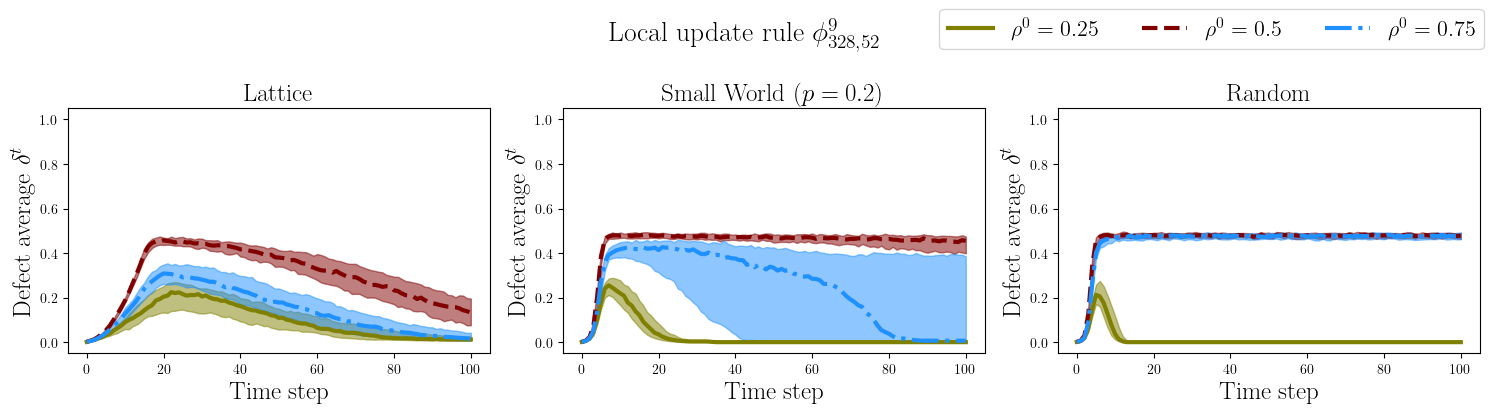

In [ ]:
# make simple totalistic CA with radius 2
resolution = 9
life_like_name = "morley"
beta, sigma = life_like_dict[life_like_name]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, B_set, S_set, iso=True)
T = 100

def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

num_config = 100
init_dens_list = [0.25, 0.5, 0.75]
init_dens_str_list = [f"$1/4$", f"$2/4$", f"$3/4$"]
init_dens_colors = ['olive', 'maroon', 'dodgerblue']
ls_list = ['-', '--', '-.']
init_damage = 1/L/L # minimal damage

fig, axs = plt.subplots(1, len(graphs), figsize=(5*len(graphs), 4))
fontsize=18
alpha_factor = 0.03

for edge, graph_name, ax in tqdm(zip(edges, graph_names, axs), total=len(graphs)):
    for init_dens, color, ls in zip(init_dens_list, init_dens_colors, ls_list):
        # find a number of initial configurations with a fixed density
        init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
        # find a number of unique defects. We can use the same function for this
        init_configs_defects = np.eye(num_nodes, dtype=int)[np.random.choice(num_nodes, num_config, replace=False)]
        # create an initial configuration with the appropriate damage
        init_configs_damage = np.bitwise_xor(init_configs, init_configs_defects)
        # run simulation over a number of time steps for the original and defect thing
        configs = model.forward(edge, tc.tensor(init_configs), T=T).numpy().astype(int)
        configs_damage = model.forward(edge, tc.tensor(init_configs_damage), T=T).numpy().astype(int)
        damage = np.bitwise_xor(configs, configs_damage)
        # calculate the mean damage over all nodes
        means_damage_over_nodes = np.mean(damage, axis=2).T
        # calcule the quartiles for each time step
        Q1_of_means = np.quantile(means_damage_over_nodes, 0.25, axis=1)
        Q2_of_means = np.quantile(means_damage_over_nodes, 0.50, axis=1)
        Q3_of_means = np.quantile(means_damage_over_nodes, 0.75, axis=1)
        # plot
        # ax.plot(means_damage_over_nodes, alpha=alpha_factor*100/num_config, color=color)
        ax.plot(Q2_of_means, lw=3, color=color, ls=ls, label=f"$\\rho^0 = {init_dens}$")
        ax.fill_between(range(T+1), Q1_of_means, Q3_of_means, lw=1, color=color, alpha=0.5)
    ax.set_title(f"{graph_name}", fontsize=fontsize)
    ax.set_xlabel("Time step", fontsize=fontsize)
    ax.set_ylabel(f"Defect average $\\delta^t$", fontsize=fontsize)
    ax.set_ylim([-0.05, 1.05])

# Add a single legend for all subplots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=len(graphs), fontsize=fontsize-2, bbox_to_anchor=(1, 1.05) )

fig.suptitle(f"Local update rule {model.__str__(latex=True)}", fontsize=fontsize+2, y=1)
fig.tight_layout()

- R5 B0 S21
- R5 B28 S2
- R5 B11 S2: seems to diverge in random networks!
- R5 B14 S17: everyone stays in their lane, and random networks come a bit together
- R5 B21 S8: divergence of the damage attractors
- R5 B12 S1: stability in CA, but damage extinction (so convergence) in random network!. Same for R5 B20 S3. Even after waiting for a long time!
- R5 B21 S10: quite funky behaviour! Looks pretty

In [35]:
from src.analysis import median_and_percentiles_over_ensemble

In [72]:
# model = LLNA(resolution, iso=True)
T = 100

resolution = 9
beta, sigma = life_like_dict["morley"]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, B_set, S_set, iso=True)

def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

# Parameters
L = 30                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast
num_nodes = L**2
rewiring_prob = 0.2     # Rewiring probability

# Create toroidal lattice and rewire
lattice_graph = create_2d_torus_lattice(L, degree=8)
small_world_graph = watts_strogatz_rewire(lattice_graph, rewiring_prob)
random_graph = watts_strogatz_rewire(lattice_graph, 1.)

# find edges
lattice_graph.to_directed()
lattice_edges = tc.tensor(lattice_graph.get_edgelist()).T
lattice_graph.to_undirected()

# find edges
small_world_graph.to_directed()
small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
small_world_graph.to_undirected()

# find edges
random_graph.to_directed()
random_edges = tc.tensor(random_graph.get_edgelist()).T
random_graph.to_undirected()

edges = [lattice_edges, small_world_edges, random_edges]

num_config = 800
init_dens_res = 51
init_dens_array = np.linspace(0,1,init_dens_res)
delta_t = 10

damage_list_per_init_dens_per_graph = []
median_list_per_graph = []
lw_perc_list_per_graph = []
up_perc_list_per_graph = []
for i, edge in enumerate(edges):
    print(f"Working on graph {i+1}.")
    damage_list_per_init_dens = []
    median_list = []
    lw_perc_list = []
    up_perc_list = []
    for init_dens in tqdm(init_dens_array, total=len(init_dens_array)):
        init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
        # run simulation over a number of time steps
        configs = model.forward(edge, tc.tensor(init_configs), T=T).numpy().astype(int)
        # find a number of unique defects. We can use the same function for this
        init_configs_defects = np.eye(num_nodes, dtype=int)[np.random.choice(num_nodes, num_config, replace=False)]
        # create an initial configuration with the appropriate damage
        init_configs_damage = np.bitwise_xor(init_configs, init_configs_defects)
        # run simulation over a number of time steps for the original and defect thing
        configs = model.forward(edge, tc.tensor(init_configs), T=T).numpy().astype(int)
        configs_damage = model.forward(edge, tc.tensor(init_configs_damage), T=T).numpy().astype(int)
        damage = np.bitwise_xor(configs, configs_damage)
        # calculate the mean damage over all nodes
        means_damage_over_nodes = np.mean(damage, axis=2).T
        damage_list_per_init_dens.append(means_damage_over_nodes)
        # calcule the median and quantiles
        median, lw_perc, up_perc = median_and_percentiles_over_ensemble(means_damage_over_nodes, delta_t)
        median_list.append(median)
        lw_perc_list.append(lw_perc)
        up_perc_list.append(up_perc)
    damage_list_per_init_dens_per_graph.append(damage_list_per_init_dens)
    median_list_per_graph.append(median_list)
    lw_perc_list_per_graph.append(lw_perc_list)
    up_perc_list_per_graph.append(up_perc_list)
damage_list_per_init_dens_per_graph = np.array(damage_list_per_init_dens_per_graph)
median_list_per_graph = np.array(median_list_per_graph)
lw_perc_list_per_graph = np.array(lw_perc_list_per_graph)
up_perc_list_per_graph = np.array(up_perc_list_per_graph)

Working on graph 1.


100%|██████████| 51/51 [21:18<00:00, 25.07s/it]


Working on graph 2.


100%|██████████| 51/51 [20:13<00:00, 23.79s/it]


Working on graph 3.


100%|██████████| 51/51 [21:23<00:00, 25.17s/it]


In [106]:
import numpy as np

# Start with an empty numpy array
result_array = np.empty((2, 0))  # Assuming each row has 3 columns
# Example 2-D data to add
arrays_to_add = np.array([
    np.array([[1, 2, 3], [4, 5, 6]]),
    np.array([[7, 8, 9], [10, 11, 12]]),
    np.array([[13, 14, 15], [16, 17, 18]])
])

# # Add 2-D arrays to the result array in a loop
# for array in arrays_to_add:
#     result_array = np.vstack((result_array, array))

# result_array
array.shape

np.mean(damage, axis=2).shape


(50, 101)

In [107]:
# TODO: I should have multiple networks per rewiring probability!

# Parameters
L = 30                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast
num_nodes = L**2
num_graphs_per_p = 16
rewiring_res = 51
rewiring_prob_array = np.logspace(-2,0,rewiring_res)

# Create toroidal lattice and rewire
lattice_graph = create_2d_torus_lattice(L, degree=8)
graphs = [[watts_strogatz_rewire(lattice_graph, rewiring_prob) for _ in range(num_graphs_per_p)] for rewiring_prob in tqdm(rewiring_prob_array, total=rewiring_res)]
edges_per_p = []
for idx in tqdm(range(rewiring_res), total=rewiring_res):
    edges = []
    for graph in graphs[idx]:
        # find edges
        graph.to_directed()
        edge = tc.tensor(graph.get_edgelist()).T
        edges.append(edge)
        graph.to_undirected()
    edges_per_p.append(edges)

num_config = 50 # can be lower, cause we're also altering the topology, and this has more or less the same effect as giving a different init config
delta_t = 10

init_dens_list = [0.25, 0.5, 0.75]
damage_list_per_graph_per_init_dens = []
median_list_per_init_dens = []
lw_perc_list_per_init_dens = []
up_perc_list_per_init_dens = []
for i, init_dens in enumerate(init_dens_list):
    print(f"Working on init_dens {i+1}.")
    damage_list_per_graph = []
    median_list = []
    lw_perc_list = []
    up_perc_list = []
    for edges in tqdm(edges_per_p, total=rewiring_res):
        # create empty array to which results from different network runs will be added
        means_damage_over_nodes = np.empty((0, T + 1))
        for edge in edges:
            init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
            # run simulation over a number of time steps
            configs = model.forward(edge, tc.tensor(init_configs), T=T).numpy().astype(int)
            # find a number of unique defects. We can use the same function for this
            init_configs_defects = np.eye(num_nodes, dtype=int)[np.random.choice(num_nodes, num_config, replace=False)]
            # create an initial configuration with the appropriate damage
            init_configs_damage = np.bitwise_xor(init_configs, init_configs_defects)
            # run simulation over a number of time steps for the original and defect thing
            configs_damage = model.forward(edge, tc.tensor(init_configs_damage), T=T).numpy().astype(int)
            damage = np.bitwise_xor(configs, configs_damage)
            # calculate the mean damage over all nodes and concatenate
            means_damage_over_nodes = np.vstack((means_damage_over_nodes, np.mean(damage, axis=2)))
        # switch indices (TODO: this is not programmed very cleanly)
        means_damage_over_nodes = means_damage_over_nodes.T
        damage_list_per_graph.append(means_damage_over_nodes)
        # calcule the median and quantiles
        median, lw_perc, up_perc = median_and_percentiles_over_ensemble(means_damage_over_nodes, delta_t)
        median_list.append(median)
        lw_perc_list.append(lw_perc)
        up_perc_list.append(up_perc)
    damage_list_per_graph_per_init_dens.append(damage_list_per_graph)
    median_list_per_init_dens.append(median_list)
    lw_perc_list_per_init_dens.append(lw_perc_list)
    up_perc_list_per_init_dens.append(up_perc_list)
damage_list_per_graph_per_init_dens = np.array(damage_list_per_graph_per_init_dens)
median_list_per_init_dens = np.array(median_list_per_init_dens)
lw_perc_list_per_init_dens = np.array(lw_perc_list_per_init_dens)
up_perc_list_per_init_dens = np.array(up_perc_list_per_init_dens)

100%|██████████| 51/51 [00:04<00:00, 10.80it/s]


Working on init_dens 1.


51it [28:54, 34.02s/it]                        


Working on init_dens 2.


51it [34:05, 40.11s/it]                        


Working on init_dens 3.


51it [32:33, 38.30s/it]                        


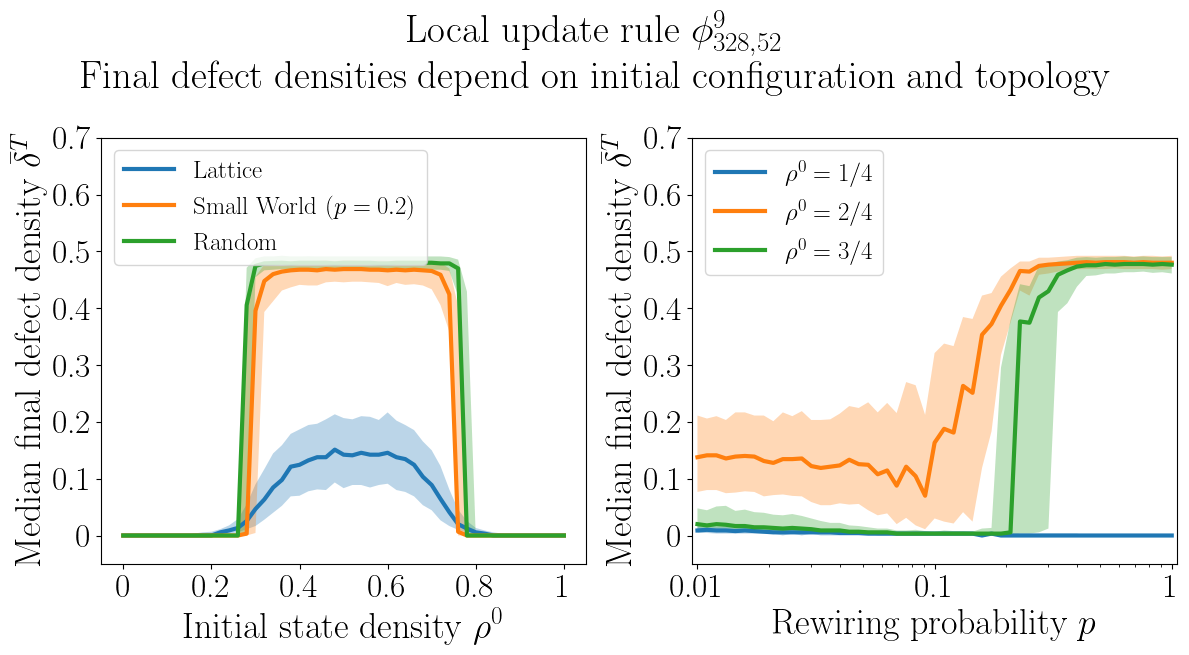

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(12,6.5))
fontsize=26

for median_list, lw_perc_list, up_perc_list, graph_name in zip(median_list_per_graph,
                                                                      lw_perc_list_per_graph,
                                                                      up_perc_list_per_graph,
                                                                      graph_names):
    axs[0].plot(init_dens_array, median_list, lw=3, label=graph_name)
    axs[0].fill_between(init_dens_array, lw_perc_list, up_perc_list, alpha=0.3)

init_dens_names = ["1/4", "2/4", "3/4"]
for median_list, lw_perc_list, up_perc_list, init_dens_name in zip(median_list_per_init_dens,
                                                                      lw_perc_list_per_init_dens,
                                                                      up_perc_list_per_init_dens,
                                                                      init_dens_names):
    axs[1].plot(rewiring_prob_array, median_list, lw=3, label=f"$\\rho^0 = {init_dens_name}$")
    axs[1].fill_between(rewiring_prob_array, lw_perc_list, up_perc_list, alpha=0.3)
    axs[1].set_xscale('log')

axs[0].set_ylabel("Median final defect density $\\bar{\\delta}^T$", fontsize=fontsize)
axs[0].set_xlabel("Initial state density $\\rho^0$", fontsize=fontsize)
axs[0].legend(fontsize=fontsize-8, loc='upper left')

axs[0].set_ylim([-0.05,0.7])
axs[0].set_xlim([-0.05, 1.05])

# left plot
xticks = [0, 0.2, 0.4, 0.6, 0.8, 1]
yticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
axs[0].set_xticks(xticks)
axs[0].set_xticklabels(xticks, fontsize=fontsize-2)
axs[0].set_yticks(yticks)
axs[0].set_yticklabels(yticks, fontsize=fontsize-2)

# right plot
axs[1].legend(fontsize=fontsize-8, loc='upper left')
axs[1].set_ylabel("Median final defect density $\\bar{\\delta}^T$", fontsize=fontsize)
axs[1].set_xlabel(f"Rewiring probability $p$", fontsize=fontsize)
axs[1].set_ylim([-0.05,0.7])
axs[1].set_xlim([0.01*0.95, 1*1.05])
xticks = [0.01, 0.1, 1]
yticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
axs[1].set_xscale('log')
axs[1].set_xticks(xticks)
axs[1].set_xticklabels(xticks, fontsize=fontsize-2)
axs[1].set_yticks(yticks)
axs[1].set_yticklabels(yticks, fontsize=fontsize-2)

fig.suptitle(f"Local update rule {model.__str__(latex=True)}\nFinal defect densities depend on initial configuration and topology", fontsize=fontsize+2, y=1)
fig.tight_layout()

# savename = f"final_defect_densities_vs_init_conf_and_topology_{model.__str__()}.pdf"
# plt.savefig(f"{savename}", bbox_inches='tight')

## Diameter of the affected subgraph

100%|██████████| 3/3 [00:02<00:00,  1.50it/s]


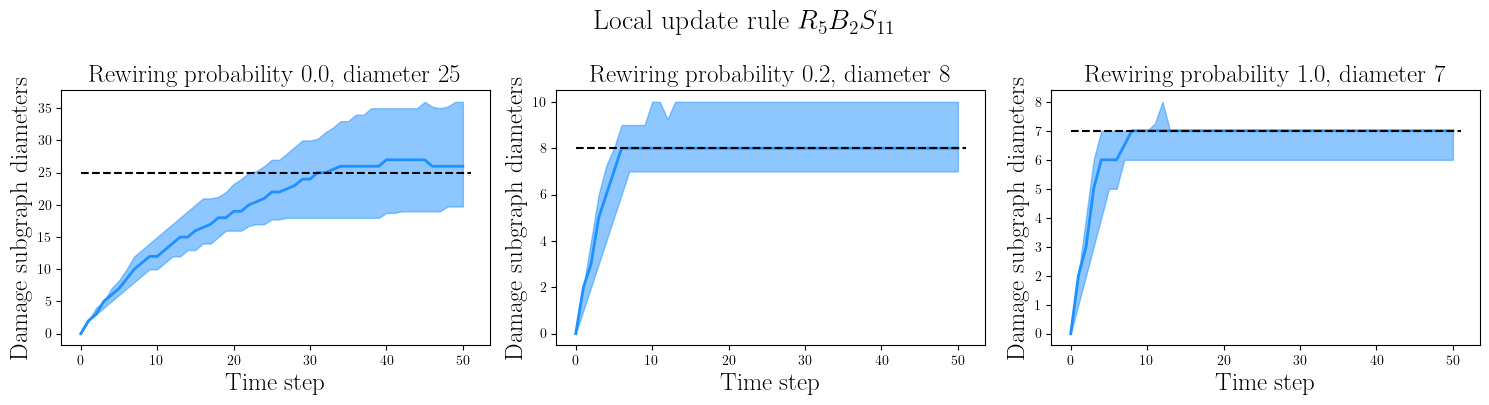

In [74]:
# make simple totalistic CA with radius 2
resolution = 5
beta = 2
sigma = 11
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, B_set, S_set, iso=True)
# model = LLNA(resolution, iso=True)
T = 50

# single-seed initial defects (one defect per node)
init_configs_defects = np.eye(num_nodes, dtype=int)
init_dens = 0.5

fig, axs = plt.subplots(1, prob_resolution, figsize=(5*prob_resolution, 4))
fontsize=18
alpha_factor = 0.03

for ws_edge, ws_graph, rewiring_prob, ax in tqdm(zip(ws_edges, ws_graphs, rewiring_probs, axs), total=prob_resolution):
    # find a number of initial configurations with a fixed density
    init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_nodes)])
    # create an initial configuration with the appropriate damage
    init_configs_damage = np.bitwise_xor(init_configs, init_configs_defects)
    # run simulation over a number of time steps for the original and defect thing
    configs = model.forward(ws_edge, tc.tensor(init_configs), T=T).numpy().astype(int)
    configs_damage = model.forward(ws_edge, tc.tensor(init_configs_damage), T=T).numpy().astype(int)
    damages = np.bitwise_xor(configs, configs_damage)
    # mark nodes with a damage history with a 1
    damages_cum = np.cumsum(damages, axis=1)
    damages_cum = np.clip(damages_cum, 0, 1)
    # define subgraph for each of the defects at all intermediate times
    Q1_diameters = []
    Q2_diameters = []
    Q3_diameters = []
    # NOTE: this is probably not coded very well (loops)
    for time in range(T+1):
        diameters = []
        for seed_idx in range(num_nodes):
            damage_cum = damages_cum[seed_idx, time]
            nodes_with_damage_history, = np.where(damage_cum)
            subG = ws_graph.subgraph(nodes_with_damage_history)
            diameter = subG.diameter()
            diameters += [diameter]
        diameters = np.array(diameters)
        Q1_of_diameters_t = np.quantile(diameters, 0.25)
        Q2_of_diameters_t = np.quantile(diameters, 0.50)
        Q3_of_diameters_t = np.quantile(diameters, 0.75)
        Q1_diameters.append(Q1_of_diameters_t)
        Q2_diameters.append(Q2_of_diameters_t)
        Q3_diameters.append(Q3_of_diameters_t)
    # plot
    graph_diam = ws_graph.diameter()
    ax.plot([0,T+1], [graph_diam,graph_diam], 'k--', zorder=10)
    ax.plot(Q2_diameters, lw=2, color=color, ls='-')
    ax.fill_between(range(T+1), Q1_diameters, Q3_diameters, lw=1, color=color, alpha=0.5)
    ax.set_title(f"Rewiring probability {round(rewiring_prob,2)}, diameter {graph_diam}", fontsize=fontsize)
    ax.set_xlabel("Time step", fontsize=fontsize)
    ax.set_ylabel("Damage subgraph diameters", fontsize=fontsize)
    # ax.set_ylim([-0.05, 1.05])

# Add a single legend for all subplots
handles, labels = axs[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper right', ncol=len(init_dens_list), fontsize=fontsize-2, bbox_to_anchor=(1, 1.05) )

fig.suptitle(f"Local update rule {model.__str__(latex=True)}", fontsize=fontsize+2, y=1)
fig.tight_layout()

This gives more rich behaviour, because now there are multiple outcomes. From the defect's perspective, the CA is no longer homogeneous, because there is a distribution of living and dead cells on it. I could look at what happens for different initial conditions.

100%|██████████| 3/3 [00:01<00:00,  2.22it/s]


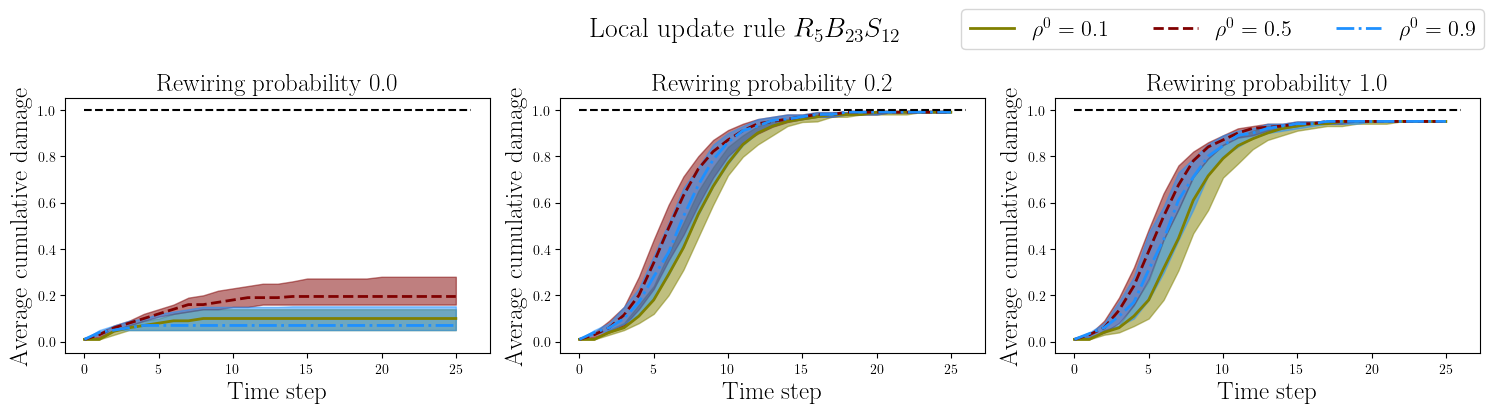

In [213]:
# make simple totalistic CA with radius 2
resolution = 5
beta = 20
sigma = 3
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
# model = LLNA(resolution, B_set, S_set, iso=True)
model = LLNA(resolution, iso=True)
T = 25

# single-seed initial defects (one defect per node)
init_configs_defects = np.eye(num_nodes, dtype=int)
init_dens_list = [0.1, 0.5, 0.9]
init_dens_colors = ['olive', 'maroon', 'dodgerblue']
init_dens_ls = ['-', '--', '-.']

fig, axs = plt.subplots(1, prob_resolution, figsize=(5*prob_resolution, 4))
fontsize=18
alpha_factor = 0.03

for ws_edge, rewiring_prob, ax in tqdm(zip(ws_edges, rewiring_probs, axs), total=prob_resolution):
    for init_dens, color, ls in zip(init_dens_list, init_dens_colors, init_dens_ls):
        # find a number of initial configurations with a fixed density
        init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_nodes)])
        # create an initial configuration with the appropriate damage
        init_configs_damage = np.bitwise_xor(init_configs, init_configs_defects)
        # run simulation over a number of time steps for the original and defect thing
        configs = model.forward(ws_edge, tc.tensor(init_configs), T=T).numpy().astype(int)
        configs_damage = model.forward(ws_edge, tc.tensor(init_configs_damage), T=T).numpy().astype(int)
        damages = np.bitwise_xor(configs, configs_damage)
        # find nodes with an activation history with a 1
        damages_cum = np.cumsum(damages, axis=1)
        damages_cum = np.clip(damages_cum, 0, 1)
        # calculate the means over all nodes
        fraction_damaged_nodes = np.mean(damages_cum, axis=2).T
        # calcule the quartiles for each time step
        Q1_of_fraction = np.quantile(fraction_damaged_nodes, 0.25, axis=1)
        Q2_of_fraction = np.quantile(fraction_damaged_nodes, 0.50, axis=1)
        Q3_of_fraction = np.quantile(fraction_damaged_nodes, 0.75, axis=1)
        # plot
        ax.plot(Q2_of_fraction, lw=2, color=color, ls=ls, label=f"$\\rho^0 = {init_dens}$")
        ax.fill_between(range(T+1), Q1_of_fraction, Q3_of_fraction, lw=1, color=color, alpha=0.5)
    # plot documenation
    ax.plot([0, T+1], [1, 1], 'k--')
    ax.set_title(f"Rewiring probability {round(rewiring_prob,2)}", fontsize=fontsize)
    ax.set_xlabel("Time step", fontsize=fontsize)
    ax.set_ylabel("Average cumulative damage", fontsize=fontsize)
    ax.set_ylim([-0.05, 1.05])

# Add a single legend for all subplots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=len(init_damage_list), fontsize=fontsize-2, bbox_to_anchor=(1, 1.05) )

fig.suptitle(f"Local update rule {model.__str__(latex=True)}", fontsize=fontsize+2, y=1)
fig.tight_layout()

Watch out for the interpretation! This only says something about nodes that have been affected EVER. It could still be very boring behaviour overall. But it does tell you which fraction of the network really doesn't care about you.

- R5 B20 S3 is again quite nice
- R5 B6 S8 is interesting, as the damage spread seems to speed up in the CA case
- R5 B6 S12 looks like a quite classic example
- R5 B6 S1 has a very large spread!
- R5 B20 S13 is cool! visible, and with interesting conclusions
- R5 B5 S1: again a large spread. Possibly favourite so far. Having a large spread is interesting, because that means that some nodes will be much more important than others!
- R5 B21 S27. Just nice and clean (but nothing really shocking)